Paquetes necesarios

In [9]:
import numpy as np
import cv2  
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

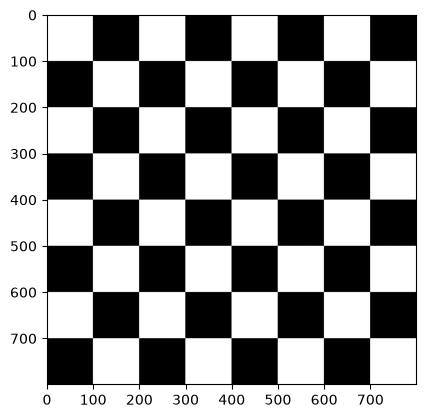

In [10]:
def ajedrez():
    tablero_img = np.zeros((800, 800, 1), dtype=np.uint8)
    for i in range(0, 800, 100):
        for j in range(0, 800, 100):
            if ((i+j)%200 == 0):
                tablero_img[i:i+100, j:j+100] = 255

    plt.imshow(tablero_img, cmap='gray', vmin=0, vmax=255)
    plt.show()

ajedrez()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

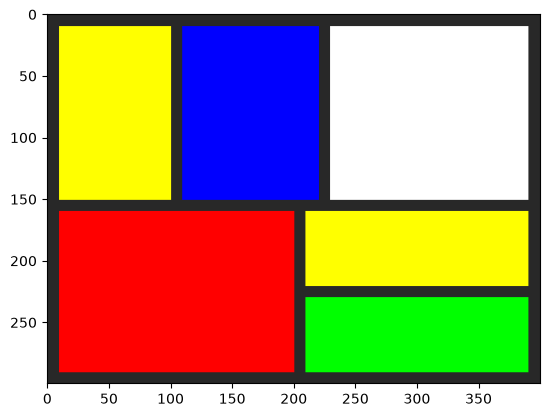

In [11]:
def mondrian():
    ancho = 400
    alto = 300
    mondrian_img = np.zeros((alto, ancho, 3), dtype=np.uint8)
    mondrian_img[:,:,:] = 40
    cv2.rectangle(mondrian_img, (10, 10), (100, int(alto/2)), (255, 255, 0), -1)
    cv2.rectangle(mondrian_img, (110, 10), (220, int(alto/2)), (0, 0, 255), -1)
    cv2.rectangle(mondrian_img, (230, 10), (ancho-10, int(alto/2)), (255, 255, 255), -1)
    cv2.rectangle(mondrian_img, (10, int(alto/2)+10), (int(ancho/2), alto-10), (255, 0, 0), -1)
    cv2.rectangle(mondrian_img, (int(ancho/2)+10, int(alto/2+10)), (ancho-10, int(alto/4)*3-5), (255, 255, 0), -1)
    cv2.rectangle(mondrian_img, (int(ancho/2)+10, int(alto/4)*3+5), (ancho-10, alto-10), (0, 255, 0), -1)
    plt.imshow(mondrian_img)
    plt.show()

mondrian()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.

In [12]:
def pixeles_cam():
    vid = cv2.VideoCapture(0)

    while(True):
        ret, frame = vid.read()
        if ret:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            min_x, min_y = np.where(gray == np.min(gray))
            max_x, max_y = np.where(gray == np.max(gray))

            # Más oscuro en azul, más claro en rojo
            cv2.circle(frame, (min_x[0], min_y[0]), 1, (255, 0, 0), 2)
            cv2.circle(frame, (max_x[0], max_y[0]), 1, (0, 0, 255), 2)

            cv2.imshow('Cam', frame)

        if cv2.waitKey(20) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

    
pixeles_cam()

**TAREA**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [13]:
def pop_art():
    vid = cv2.VideoCapture(0)

    w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))//2
    h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))// 2

    collage = np.zeros((h*2,w*2), dtype = np.uint8)
    tl = collage[0:h,0:w]
    tr = collage[0:h,w:w+w]
    bl = collage[h:h+h,0:w]
    br = collage[h:h+h,w:w+w]

    while True:
        ret, frameIN = vid.read()

        if ret:
            frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

            grey = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            edges = cv2.Canny(grey, 100, 200)
            invert = cv2.bitwise_not(edges)
            
            tl[:,:] = edges
            tr[:,:] = invert
            bl[:,:] = invert
            br[:,:] = edges

            cv2.imshow('Cam', collage)

        if cv2.waitKey(20) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

pop_art()

#### Documentación

https://docs.opencv.org/4.13.0/da/d22/tutorial_py_canny.html

https://stackoverflow.com/questions/19580102/inverting-image-in-python-with-opencv

https://www.geeksforgeeks.org/python/arithmetic-operations-on-images-using-opencv-set-2-bitwise-operations-on-binary-images/

#### Uso de IA


**Pregunta**:

Hola mi negro. Quiero calcular los bordes de  una imagen en blanco y negro con python. Puedo hacerlo con OpenCV? Dime solo el nombre la función para calcular los bordes. Respuesta concisa

**Respuesta**:

Sí, puedes usarlo. La función es:

```py
cv2.Canny()
```